# 01 · Signaling

The first of the four themes, and the template the other three follow.

**Panel:** Foxo3a, Foxo1, FGFR1, PDGFRα, β-Catenin, YAP1, p-S6, p-AKT, c-Myc, RNAPII-pS5

This theme has something the others do not: a **prediction**. Five of the eighteen
compounds target the PI3K–AKT–mTOR axis, so we know in advance roughly what should
move. That makes signaling the right place to learn what a real effect looks like in
this dataset — and what a real *absence* looks like.

Five steps, repeated in every theme chapter:

1. select the panel
2. per-condition effects, as a heatmap
3. rank the effects, honestly
4. an embedding built from this theme alone
5. what happens to single cells over time

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

sys.path.insert(0, str(Path.cwd().parents[1] / "src"))

from mcs2026 import analysis, panels, plotting
from mcs2026.config import H5AD_SLIM

plotting.set_style()
pd.set_option("display.width", 140)

THEME = "signaling"

wells = pd.read_parquet(H5AD_SLIM.with_name("mcs2026_wells.parquet"))
cells = sc.read_h5ad(H5AD_SLIM.with_name("mcs2026_clean.h5ad"))
print(f"{len(wells)} wells, {cells.n_obs:,} cells")

223 wells, 65,349 cells


## 1. The panel

In [2]:
markers = analysis.panel_markers(THEME, wells.columns)
print(f"{len(markers)} of {len(panels.markers(THEME))} panel markers present:")
markers

10 of 10 panel markers present:


['Foxo3a',
 'Foxo1',
 'FGFR1',
 'PDGFRa',
 'beta-Catenin',
 'YAP1',
 'p-S6',
 'p-AKT',
 'c-Myc',
 'RNAPII-pS5']

Where each was imaged matters, because Step 15 showed that signal level depends on
the round. The normalisation handles it, but it is worth seeing which markers came from
the fragile late rounds:

In [3]:
lookup = cells.var[cells.var.marker.isin(markers) & (cells.var.statistic == "mean_intensity")]
lookup[["marker", "round", "channel", "intensity_threshold"]].sort_values("round").reset_index(drop=True)

,marker,round,channel,intensity_threshold
0,beta-Catenin,0,FITC,1000.0
1,Foxo3a,0,Texas Red,500.0
2,FGFR1,1,Cy5,500.0
3,YAP1,8,FITC,1500.0
4,Foxo1,8,Texas Red,300.0
5,p-S6,15,Cy5,500.0
6,RNAPII-pS5,17,FITC,2500.0
7,PDGFRa,18,FITC,800.0
8,c-Myc,19,Cy5,400.0
9,p-AKT,24,Cy5,700.0


## 2. Effects per condition

Every value below is in **control-well standard deviations**: how far a condition sits
from the DMSO wells of the same timepoint, in units of how much two control wells
differ from each other.

In [4]:
effects = analysis.effect_table(wells, markers, by_timepoint=False)
effects.round(2)

,Foxo3a,Foxo1,FGFR1,PDGFRa,beta-Catenin,YAP1,p-S6,p-AKT,c-Myc,RNAPII-pS5
condition,,,,,,,,,,
Cycloheximide,-1.22,-2.45,-6.87,-1.13,-4.98,-2.40,0.26,-1.29,-0.90,1.05
Dorsomorphin,0.76,-0.54,-1.22,0.05,-0.17,-0.25,0.71,-0.29,0.13,0.33
Geldanamycin,-1.04,-2.25,-2.01,-0.16,-0.94,-1.75,-0.27,-0.93,-1.56,-0.93
Glucose,-0.06,-0.64,-0.42,0.92,0.16,-0.96,-0.24,0.13,-0.33,0.28
IGF,0.61,-0.66,-0.01,0.53,0.74,0.21,0.50,0.12,0.09,1.26
IL6,-0.27,-0.94,0.02,1.12,-2.18,-1.55,0.41,-0.53,0.14,-0.26
LipidMix,0.88,-1.89,-1.41,-0.18,-1.17,-0.68,-0.46,-0.96,-1.66,0.01
MEM AA,-0.27,-0.96,-0.53,0.17,-0.33,-0.61,0.37,0.21,-0.36,0.27
MK-2206,0.61,-2.90,-4.04,-0.06,0.16,-0.66,-3.29,-0.80,-1.15,2.39


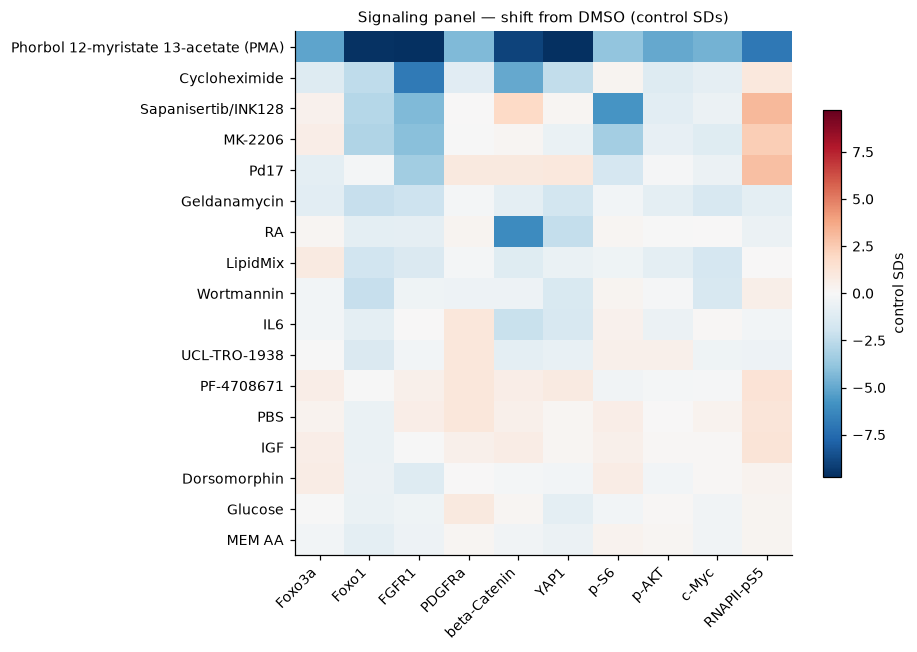

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 6))
order = effects.abs().mean(axis=1).sort_values(ascending=False).index
matrix = effects.loc[order]
limit = np.nanpercentile(np.abs(matrix.values), 99)
im = ax.imshow(matrix.values, cmap="RdBu_r", vmin=-limit, vmax=limit, aspect="auto")
ax.set(xticks=range(len(markers)), yticks=range(len(order)), yticklabels=order)
ax.set_xticks(range(len(markers)))
ax.set_xticklabels(markers, rotation=45, ha="right")
ax.set_title(f"{THEME.capitalize()} panel — shift from DMSO (control SDs)")
fig.colorbar(im, ax=ax, shrink=0.7, label="control SDs")
fig.tight_layout()

Two things jump out, and only one of them is about signaling.

**PMA is the whole top row.** As [Step 16](../part3_analysis/1_preparation/03_normalisation.ipynb) showed, it moves everything. It is a real
effect and it is not a *signaling-specific* effect, so from here on we set it aside and
look at the other seventeen. It comes back in [chapter 05](05_integration.ipynb).

**Below PMA, the pattern is structured**, not noise: particular conditions move
particular markers, and the same markers move together.

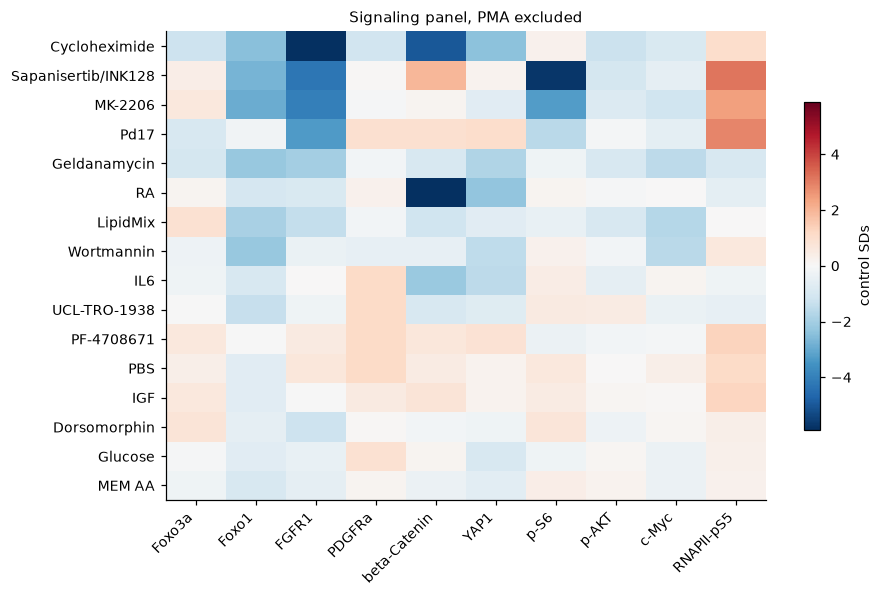

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
without_outlier = effects.drop(index=analysis.OUTLIER_CONDITION, errors="ignore")
order = without_outlier.abs().mean(axis=1).sort_values(ascending=False).index
matrix = without_outlier.loc[order]
limit = np.nanpercentile(np.abs(matrix.values), 99)
im = ax.imshow(matrix.values, cmap="RdBu_r", vmin=-limit, vmax=limit, aspect="auto")
ax.set(yticks=range(len(order)), yticklabels=order)
ax.set_xticks(range(len(markers)))
ax.set_xticklabels(markers, rotation=45, ha="right")
ax.set_title(f"{THEME.capitalize()} panel, PMA excluded")
fig.colorbar(im, ax=ax, shrink=0.7, label="control SDs")
fig.tight_layout()

## 3. Rank the effects — honestly

In [7]:
ranked = analysis.rank_effects(wells, markers)
ranked.head(15).round(3)

,condition,marker,shift,n_wells,p,p_floor,abs_shift,at_p_floor
0,Cycloheximide,FGFR1,-6.875,12,0.000,0.0,6.875,False
1,RA,beta-Catenin,-6.123,12,0.000,0.0,6.123,False
2,Sapanisertib/INK128,p-S6,-5.717,12,0.000,0.0,5.717,False
3,Cycloheximide,beta-Catenin,-4.978,12,0.000,0.0,4.978,False
4,Sapanisertib/INK128,FGFR1,-4.257,12,0.010,0.0,4.257,False
5,MK-2206,FGFR1,-4.038,12,0.003,0.0,4.038,False
6,Pd17,FGFR1,-3.346,12,0.025,0.0,3.346,False
7,MK-2206,p-S6,-3.288,12,0.001,0.0,3.288,False
8,Sapanisertib/INK128,RNAPII-pS5,3.155,12,0.000,0.0,3.155,False
9,MK-2206,Foxo1,-2.897,12,0.000,0.0,2.897,False


:::{warning}
Look at the `p` and `p_floor` columns together. With 3 treated wells against 20 control
wells, the smallest achievable p-value is fixed by the design; `at_p_floor` marks the
rows that have hit it. A row at the floor is **not** more significant than another row
at the floor, no matter how different their effect sizes are.

This is why the column that should drive your reading is `shift`, in control SDs, and
not `p`.
:::

In [8]:
print(f"{ranked.at_p_floor.sum()} of {len(ranked)} comparisons sit exactly at the p-value floor")
ranked.groupby("condition")["abs_shift"].mean().sort_values(ascending=False).head(8).round(2)

0 of 160 comparisons sit exactly at the p-value floor


condition
Cycloheximide          2.25
Sapanisertib/INK128    2.01
MK-2206                1.61
Pd17                   1.26
Geldanamycin           1.18
RA                     1.16
LipidMix               0.93
Wortmannin             0.80
Name: abs_shift, dtype: float32

### The prediction

Sapanisertib/INK128 inhibits mTOR. mTORC1 activates S6 kinase, which phosphorylates
ribosomal protein S6. So p-S6 should fall.

In [9]:
analysis.compare_to_control(wells, "p-S6", "Sapanisertib/INK128")

,timepoint,n_treated,n_control,shift,p,p_floor
0,36,3,5,-7.77,0.0357,0.0357
1,48,3,5,-7.46,0.0357,0.0357
2,60,3,5,-6.31,0.0357,0.0357
3,84,3,5,-1.33,0.0357,0.0357


In [10]:
analysis.compare_to_control(wells, "p-S6", "MK-2206")

,timepoint,n_treated,n_control,shift,p,p_floor
0,36,3,5,-5.43,0.0357,0.0357
1,48,3,5,-4.05,0.0357,0.0357
2,60,3,5,-3.60,0.0357,0.0357
3,84,3,5,-0.07,0.5714,0.0357


It does — several control SDs down at 36, 48 and 60 hours, for both the mTOR inhibitor
and the AKT inhibitor upstream of it. And it fades by 84 h, which is what you would
expect from a compound that is consumed or adapted to.

### The prediction that fails

The obvious readout for an AKT inhibitor is phospho-AKT.

In [11]:
pd.concat(
    [analysis.compare_to_control(wells, "p-AKT", c).assign(condition=c)
     for c in ["MK-2206", "Wortmannin", "Sapanisertib/INK128"]]
)[["condition", "timepoint", "shift", "p", "p_floor"]]

,condition,timepoint,shift,p,p_floor
0,MK-2206,36,-0.94,0.1429,0.0357
1,MK-2206,48,0.47,0.7857,0.0357
2,MK-2206,60,-2.27,0.0357,0.0357
3,MK-2206,84,-0.45,0.7857,0.0357
0,Wortmannin,36,-0.12,0.7857,0.0357
1,Wortmannin,48,0.35,1.0000,0.0357
2,Wortmannin,60,-0.72,0.7857,0.0357
3,Wortmannin,84,-0.07,0.7857,0.0357
0,Sapanisertib/INK128,36,-1.59,0.0714,0.0357
1,Sapanisertib/INK128,48,0.05,1.0000,0.0357


Nothing moves. This is the single most useful result in the chapter, because the
temptation is to assume the experiment failed. Three reasons it has not:

- **Feedback.** Blocking mTORC1 relieves a negative feedback loop onto the receptor,
  which *raises* AKT phosphorylation. The drug pushes down, the feedback pushes up.
- **Epitope fragility.** p-AKT sits in round 24, near the end of 18 elution cycles.
  Phospho-epitopes are the first thing a 4i panel loses.
- **Downstream integrates.** p-S6 reflects sustained pathway output; a single
  phospho-site is a snapshot of a fast equilibrium.

The pathway *is* visible — one step sideways:

In [12]:
pd.concat(
    [analysis.compare_to_control(wells, "Foxo1", c).assign(condition=c)
     for c in ["MK-2206", "Wortmannin", "Sapanisertib/INK128"]]
)[["condition", "timepoint", "shift", "p"]]

,condition,timepoint,shift,p
0,MK-2206,36,-1.90,0.2500
1,MK-2206,48,-3.52,0.0357
2,MK-2206,60,-4.27,0.0357
3,MK-2206,84,-1.91,0.0714
0,Wortmannin,36,-2.11,0.2500
1,Wortmannin,48,-1.08,0.7857
2,Wortmannin,60,-3.51,0.0357
3,Wortmannin,84,-2.20,0.0357
0,Sapanisertib/INK128,36,-0.93,0.3929
1,Sapanisertib/INK128,48,-2.55,0.0714


**Foxo1 falls for all three inhibitors, at every timepoint.** FoxO transcription factors
are direct AKT substrates. This is the pathway signature: not in the phospho-antibody
you would have picked first, but in a downstream target and a downstream effector.

## 4. An embedding of this theme alone

A PCA over *all* 2,587 features answers the question "how do these wells differ in any
way at all". A PCA over ten signaling markers answers "how do these wells differ in
their signaling" — a smaller question with a readable answer.

In [13]:
from sklearn.decomposition import PCA

usable = wells[wells.condition != analysis.OUTLIER_CONDITION]
matrix = usable[markers].fillna(0).values
pca = PCA(n_components=4, random_state=0).fit(matrix)
coords = pca.transform(matrix)
print("variance explained:", pca.explained_variance_ratio_[:4].round(3))

variance explained: [0.333 0.277 0.134 0.073]


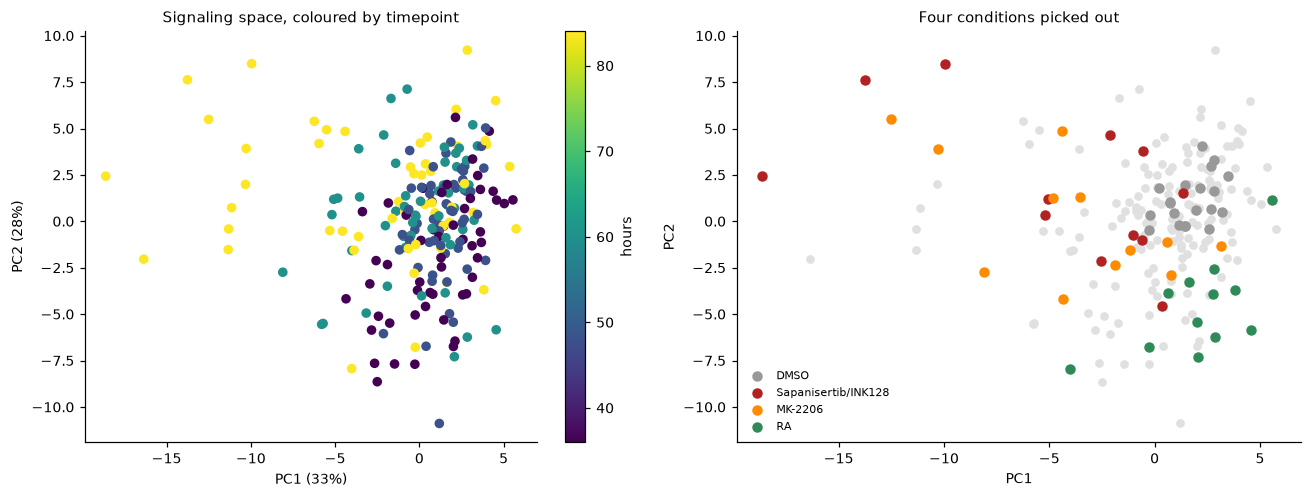

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
timepoints = usable.timepoint.values
scatter = axes[0].scatter(coords[:, 0], coords[:, 1], c=timepoints, cmap="viridis", s=28)
axes[0].set(xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.0%})",
            ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.0%})",
            title="Signaling space, coloured by timepoint")
fig.colorbar(scatter, ax=axes[0], label="hours")

highlight = {"DMSO": "0.6", "Sapanisertib/INK128": "firebrick",
             "MK-2206": "darkorange", "RA": "seagreen"}
axes[1].scatter(coords[:, 0], coords[:, 1], c="0.88", s=22)
for condition, colour in highlight.items():
    mask = (usable.condition == condition).values
    axes[1].scatter(coords[mask, 0], coords[mask, 1], c=colour, s=34, label=condition)
axes[1].set(xlabel="PC1", ylabel="PC2", title="Four conditions picked out")
axes[1].legend(fontsize=7)
fig.tight_layout()

In [15]:
loadings = pd.DataFrame(pca.components_[:2].T, index=markers, columns=["PC1", "PC2"])
loadings.reindex(loadings.PC1.abs().sort_values(ascending=False).index).round(2)

,PC1,PC2
FGFR1,0.87,0.06
RNAPII-pS5,-0.27,0.27
Foxo1,0.24,0.30
beta-Catenin,-0.20,0.71
c-Myc,0.16,0.20
p-S6,0.13,0.08
PDGFRa,0.11,0.15
p-AKT,0.11,0.11
Foxo3a,0.04,0.23
YAP1,0.03,0.44


The loadings say what the axes mean. Read them before interpreting any position in the
plot — a point being "to the right" is only informative once you know what PC1 is made
of.

## 5. Single cells, not just wells

Everything above collapsed each well to a mean. That is right for *testing*, because
the well is the replicate. But it throws away the thing imaging gives you that a plate
reader does not: the distribution.

A shift in the mean can happen two ways — every cell moves a little, or a subpopulation
moves a lot — and those are different biology.

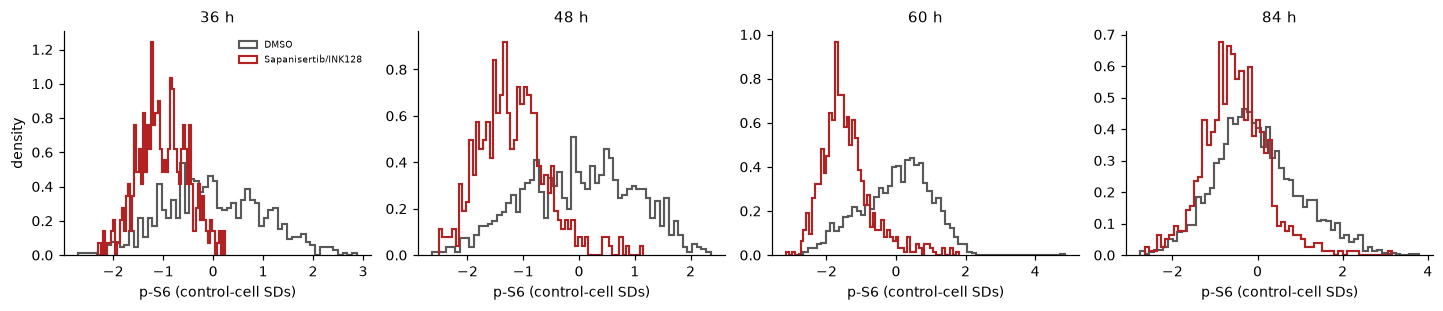

In [16]:
def marker_column(marker: str) -> str:
    match = cells.var[(cells.var.marker == marker)
                      & (cells.var.statistic == "mean_intensity")
                      & (cells.var.family == "Intensity")]
    return match.index[0]

column = marker_column("p-S6")
frame = pd.DataFrame({
    "value": np.asarray(cells[:, column].X).ravel(),
    "condition": cells.obs.condition.astype(str).values,
    "timepoint": cells.obs.timepoint_h.astype(int).values,
})

fig, axes = plotting.panel_grid(4, ncols=4, size=(3.3, 2.9))
for ax, timepoint in zip(axes, [36, 48, 60, 84]):
    block = frame[frame.timepoint == timepoint]
    for condition, colour in [("DMSO", "0.35"), ("Sapanisertib/INK128", "firebrick")]:
        values = block.loc[block.condition == condition, "value"]
        ax.hist(values, bins=60, histtype="step", density=True,
                color=colour, linewidth=1.4, label=condition)
    ax.set(title=f"{timepoint} h", xlabel="p-S6 (control-cell SDs)")
    if timepoint == 36:
        ax.set_ylabel("density")
        ax.legend(fontsize=6)
fig.tight_layout()

The whole distribution shifts left at 36–60 h, rather than a subpopulation splitting
off. So mTOR inhibition here is a **uniform** effect on the population: every cell
lowers its p-S6, rather than some fraction of cells switching off.

That distinction is invisible in the well means, and it is the reason to look.

## 6. One number for the theme

For [chapter 05](05_integration.ipynb) we need a single summary per condition, so the four themes can be
compared:

In [17]:
summary = analysis.theme_summary(wells, markers)
summary.head(8).round(2)

condition
Phorbol 12-myristate 13-acetate (PMA)    6.88
Cycloheximide                            2.25
Sapanisertib/INK128                      2.01
MK-2206                                  1.61
Pd17                                     1.26
Geldanamycin                             1.18
RA                                       1.16
LipidMix                                 0.93
dtype: float32

In [18]:
summary.to_frame(THEME).to_parquet(H5AD_SLIM.with_name(f"theme_{THEME}.parquet"))
print(f"saved theme summary for {THEME}")

saved theme summary for signaling


---

## Exercises

### 1. Which marker separates the timepoints?

PC1 above is coloured by timepoint and shows clear structure. Which markers load on it,
and does that make sense for cells differentiating over 36–84 hours?

:::{admonition} Solution
:class: dropdown

```python
loadings.PC1.sort_values()
```

Look for the pluripotency-associated and proliferation-associated markers. Cells left
in culture for 84 h are further along in differentiation than at 36 h, so markers
tracking that transition should dominate the axis that separates timepoints. If instead
PC1 loads mostly on one noisy marker, you are looking at a technical axis, and the
marker-level control SDs from [Step 13](../part3_analysis/1_preparation/02_quality_control.ipynb) will tell you which.
:::

### 2. Is IGF the mirror image of the inhibitors?

IGF activates the PI3K–AKT pathway; MK-2206 and INK128 inhibit it. If the panel is
reading the pathway, IGF should move the same markers in the opposite direction. Test
it on p-S6 and Foxo1. Does it?

:::{admonition} Solution
:class: dropdown

```python
for marker in ["p-S6", "Foxo1", "p-AKT"]:
    print(marker)
    print(analysis.compare_to_control(wells, marker, "IGF"))
```

The effect is much weaker than for the inhibitors, and that is worth thinking about
rather than dismissing. The cells are already growing in medium containing growth
factors, so the pathway is not off to begin with — there is far more room to inhibit a
active pathway than to further activate one. Asymmetry between activation and
inhibition is normal, and it is a reason to be careful about reading a weak effect as
"no pathway involvement".
:::

### 3. Repeat this chapter for another panel

Every step above is panel-agnostic. Change `THEME` to `"cell_cycle"` and re-run.
Which conditions move Cyclin A2, p21 and Ki67, and is that consistent with what those
compounds do?

:::{admonition} Solution
:class: dropdown

```python
THEME = "cell_cycle"
markers = analysis.panel_markers(THEME, wells.columns)
analysis.rank_effects(wells, markers).head(10)
```

Expect Cycloheximide (translation block) and PMA to show up. Cyclin A2 marks S/G2 and
Ki67 marks any cycling cell, so a compound that arrests the cycle should lower both
while p21, a cyclin-dependent kinase inhibitor, may rise.

This is exactly what chapters 04–06 do with the other three panels — the code does not
change, only the biology you bring to reading it.
:::

---

**Next:** [02 · Cell-specific mechanics](02_mechanics.ipynb).